**Funnel & Retention Analysis**

Análisis completo del embudo de conversión y retención de usuarios en TiendasOnline.

Mediante SQL y análisis de cohortes, identificamos en qué etapas se pierden más usuarios (desde descubrimiento hasta compra) y evaluamos la retención a lo largo del tiempo. El proyecto incluye construcción de embudos multietapa con CTEs, cálculo de tasas de conversión, análisis por país y dispositivo, segmentación por cohortes (D7, D14, D21, D28), y simulaciones de mejora accionables. Ideal para entender el comportamiento del usuario y optimizar la experiencia de compra.

In [ ]:
SELECT DISTINCT event_name
FROM tiendasonline_funnel
ORDER BY event_name;

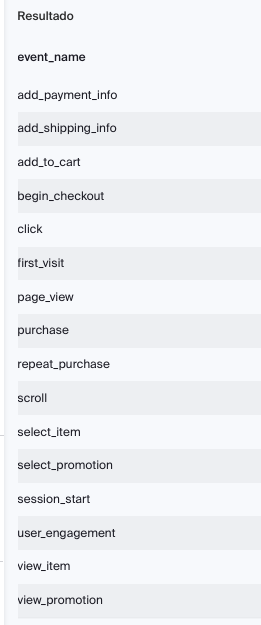

A continuación calculamos con CTEs, cuántos usuarios alcanzan cada etapa del Embudo General, desde la primera visita hasta la compra.

In [ ]:
WITH first_visits AS (
  SELECT DISTINCT user_id,country
  FROM tiendasonline_funnel
  WHERE event_name = 'first_visit'
    AND event_date BETWEEN '2025-01-01' AND '2025-08-31'
),
select_item AS (
  SELECT DISTINCT user_id,country
  FROM tiendasonline_funnel
  WHERE event_name IN ('select_item', 'select_promotion')
    AND event_date BETWEEN '2025-01-01' AND '2025-08-31'
),
add_to_cart AS (
  SELECT DISTINCT user_id,country
  FROM tiendasonline_funnel
  WHERE event_name = 'add_to_cart'
    AND event_date BETWEEN '2025-01-01' AND '2025-08-31'
),
begin_checkout AS (
  SELECT DISTINCT user_id,country
  FROM tiendasonline_funnel
  WHERE event_name = 'begin_checkout'
    AND event_date BETWEEN '2025-01-01' AND '2025-08-31'
),
add_shipping_info AS (
  SELECT DISTINCT user_id,country
  FROM tiendasonline_funnel
  WHERE event_name = 'add_shipping_info'
    AND event_date BETWEEN '2025-01-01' AND '2025-08-31'
),
add_payment_info AS (
  SELECT DISTINCT user_id,country
  FROM tiendasonline_funnel
  WHERE event_name = 'add_payment_info'
    AND event_date BETWEEN '2025-01-01' AND '2025-08-31'
),
purchase AS (
  SELECT DISTINCT user_id,country
  FROM tiendasonline_funnel
  WHERE event_name = 'purchase'
    AND event_date BETWEEN '2025-01-01' AND '2025-08-31'
),

funnel_counts AS(
SELECT
    fv.country,
  COUNT(fv.user_id) AS usuarios_first_visit,
  COUNT(si.user_id) AS usuarios_select_item,
  COUNT(a.user_id) AS usuarios_add_to_cart,
  COUNT(bc.user_id) AS usuarios_begin_checkout,
  COUNT(asi.user_id) AS usuarios_add_shipping_info,
  COUNT(api.user_id) AS usuarios_add_payment_info,
  COUNT(p.user_id) AS usuarios_purchase

    FROM first_visits fv

LEFT JOIN select_item si        ON fv.user_id = si.user_id AND fv.country = si.country
LEFT JOIN add_to_cart a         ON fv.user_id = a.user_id AND fv.country = a.country
LEFT JOIN begin_checkout bc     ON fv.user_id = bc.user_id AND fv.country = bc.country
LEFT JOIN add_shipping_info asi ON fv.user_id = asi.user_id AND fv.country = asi.country
LEFT JOIN add_payment_info api  ON fv.user_id = api.user_id AND fv.country = api.country
LEFT JOIN purchase p            ON fv.user_id = p.user_id AND fv.country = p.country

    GROUP BY fv.country
)
SELECT
    country,
    usuarios_select_item * 100.0 / NULLIF(usuarios_first_visit, 0) AS conversion_select_item,
     usuarios_add_to_cart*100.0 / NULLIF(usuarios_first_visit, 0) AS conversion_add_to_cart,
    usuarios_begin_checkout*100.0 / NULLIF(usuarios_first_visit, 0) AS conversion_begin_checkout,
    usuarios_add_shipping_info*100.0 / NULLIF(usuarios_first_visit, 0) AS conversion_add_shipping_info,
    usuarios_add_payment_info*100.0 / NULLIF(usuarios_first_visit, 0) AS conversion_add_payment_info,
    usuarios_purchase *100.0 / NULLIF(usuarios_first_visit, 0) AS conversion_purchase

   FROM funnel_counts
ORDER BY conversion_purchase DESC;



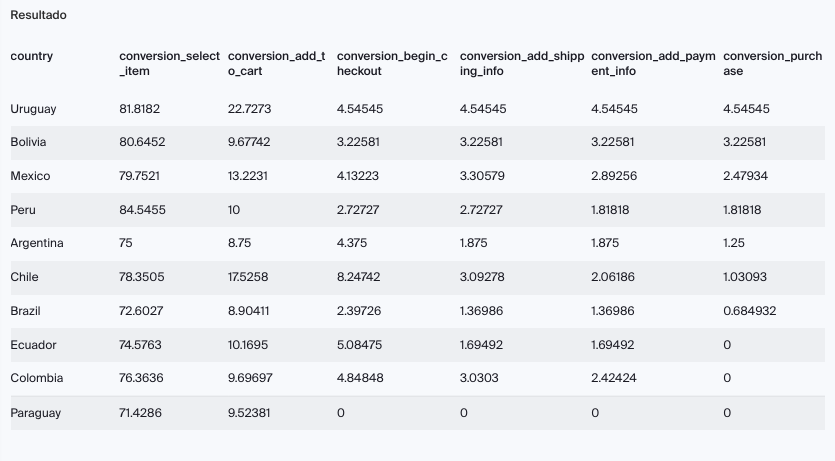

A continuación contamos usuarios activos acumulados por país (D7, D14, D21, D28) desde su registro, en el rango 2025-01-01 → 2025-08-31, al día 7, día 14, día 21 y día 28.

In [ ]:
SELECT
  country,
  COUNT(DISTINCT CASE WHEN day_after_signup >=7 AND active = 1 THEN user_id END) AS users_d7,
    COUNT(DISTINCT CASE WHEN day_after_signup >=14 AND active = 1 THEN user_id END) AS users_d14,
    COUNT(DISTINCT CASE WHEN day_after_signup >=21 AND active = 1 THEN user_id END) AS users_d21,
    COUNT(DISTINCT CASE WHEN day_after_signup >=28 AND active = 1 THEN user_id END) AS users_d28

FROM tiendasonline_retention
WHERE activity_date BETWEEN '2025-01-01' AND '2025-08-31'
GROUP BY country
ORDER BY country;


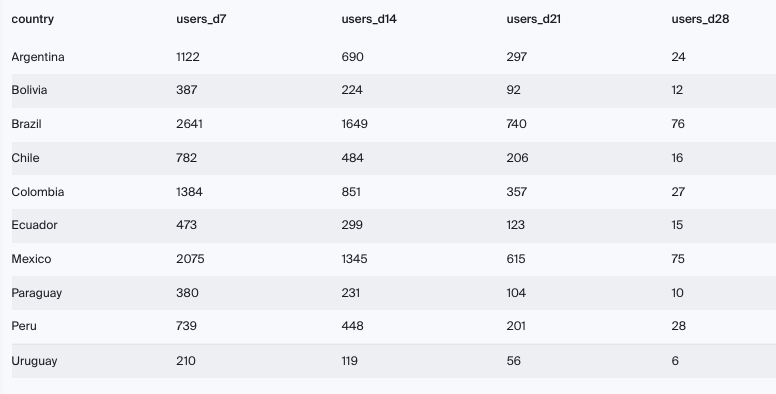

Convertimos los nùmeros en porcentajes

In [ ]:
SELECT
  country,
    ROUND(
    COUNT(DISTINCT CASE WHEN day_after_signup >= 7  AND active = 1 THEN user_id END) *100.0 /
     NULLIF(COUNT(DISTINCT user_id), 0) ,1)AS retention_d7_pct,
    ROUND(
  COUNT(DISTINCT CASE WHEN day_after_signup >= 14 AND active = 1 THEN user_id END) *100.0 /
     NULLIF(COUNT(DISTINCT user_id), 0) ,1) AS retention_d14_pct,
    ROUND(
  COUNT(DISTINCT CASE WHEN day_after_signup >= 21 AND active = 1 THEN user_id END)*100.0 /
     NULLIF(COUNT(DISTINCT user_id), 0) ,1)  AS retention_d21_pct ,
    ROUND(
  COUNT(DISTINCT CASE WHEN day_after_signup >= 28 AND active = 1 THEN user_id END)  *100.0 /
     NULLIF(COUNT(DISTINCT user_id), 0) ,1) AS retention_d28_pct
FROM tiendasonline_retention
WHERE activity_date BETWEEN '2025-01-01' AND '2025-08-31'
GROUP BY country
ORDER BY country;

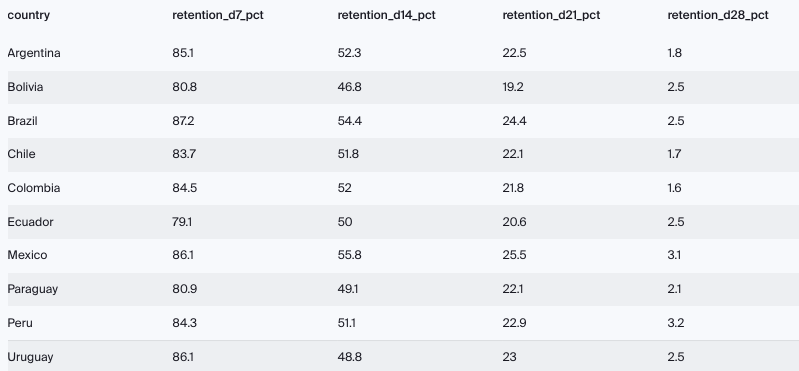

Calcular retención por cohorte y periodo D7, D14, D21, D28

Ahora, para cada cohorte mensual (YYYY-MM), calculamos el % de usuarios activos al día 7, 14, 21, y 28  desde su registro.

In [ ]:
WITH cohort AS (
SELECT
user_id,
TO_CHAR(DATE_TRUNC('month', MIN(signup_date)), 'YYYY-MM') AS cohort
FROM tiendasonline_retention
GROUP BY user_id
),
activity AS (
SELECT mr.user_id,
    c.cohort,
    mr.day_after_signup,
    mr.active
    FROM tiendasonline_retention mr
LEFT JOIN cohort c
    ON mr.user_id=c.user_id
WHERE mr.activity_date BETWEEN '2025-01-01' AND '2025-08-31'
)
   SELECT
    cohort,
ROUND(
  100.0 * COUNT(DISTINCT CASE WHEN day_after_signup >= 7 AND active = 1 THEN user_id END)
  / NULLIF(COUNT(DISTINCT user_id), 0), 1
) AS retention_d7_pct,
ROUND(
  100.0 * COUNT(DISTINCT CASE WHEN day_after_signup >= 14 AND active = 1 THEN user_id END)
  / NULLIF(COUNT(DISTINCT user_id), 0), 1
) AS retention_d14_pct,
    ROUND(
  100.0 * COUNT(DISTINCT CASE WHEN day_after_signup >= 21 AND active = 1 THEN user_id END)
  / NULLIF(COUNT(DISTINCT user_id), 0), 1
) AS retention_d21_pct,
    ROUND(
  100.0 * COUNT(DISTINCT CASE WHEN day_after_signup >= 28 AND active = 1 THEN user_id END)
  / NULLIF(COUNT(DISTINCT user_id), 0), 1
) AS retention_d28_pct


FROM activity
GROUP BY cohort
ORDER BY cohort;

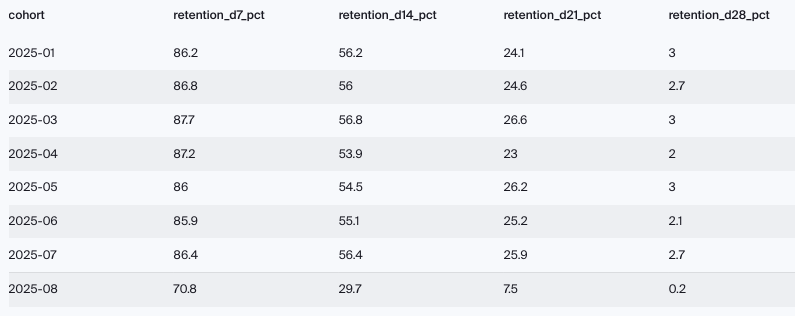